## ResNet

#### 1. Setup and Imports

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.getcwd())
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'src')):
    PROJECT_ROOT = os.path.abspath('..')

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints')
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

import torch
import wandb
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from src.dataset import get_dataloaders
from src.models import CustomResNet
from src.utils import generate_run_name, log_confusion_matrix, EarlyStopping, EMOTION_LABELS, load_wandb_results
from src.train import train

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
wandb.login()
print('Wandb ready')


Project root: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\l.chitishvili\_netrc.


Using device: cuda


wandb: Currently logged in as: lchit22 (lchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Wandb ready


#### 2. Data Loading

In [2]:
for aug in ['none', 'light', 'strong']:
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir=DATA_DIR,
        aug_mode=aug,
        batch_size=64
    )
    images, labels = next(iter(train_loader))
    print(f'aug={aug} | batch shape: {images.shape} | labels shape: {labels.shape}')

print('Data loading works correctly')


aug=none | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=light | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
aug=strong | batch shape: torch.Size([64, 1, 48, 48]) | labels shape: torch.Size([64])
Data loading works correctly


#### 3. Model Definition

In [3]:
model = CustomResNet(dropout=0.5)
dummy = torch.randn(4, 1, 48, 48)
out = model(dummy)
print(f'CustomResNet output shape: {out.shape}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')


CustomResNet output shape: torch.Size([4, 7])
Total parameters: 223,559


#### 3b. Forward and Backward Check

In [4]:
model = CustomResNet(dropout=0.5)
train_loader, _, _ = get_dataloaders(data_dir=DATA_DIR, aug_mode='none', batch_size=4)
images, labels = next(iter(train_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

model = model.to(DEVICE)
out = model(images)
assert out.shape == (images.size(0), 7), f"Expected (batch, 7), got {out.shape}"
assert not torch.isnan(out).any() and not torch.isinf(out).any(), "Forward pass produced NaN/inf"

loss = torch.nn.functional.cross_entropy(out, labels)
model.zero_grad()
loss.backward()

bad = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if p.grad is None:
        bad.append(f"{name}: no grad")
    elif torch.isnan(p.grad).any() or torch.isinf(p.grad).any():
        bad.append(f"{name}: NaN/inf grad")
    elif p.grad.abs().sum() == 0:
        bad.append(f"{name}: zero grad")

assert not bad, "Backward check failed:\n" + "\n".join(bad)
print(f"Forward OK: output {tuple(out.shape)}, loss={loss.item():.4f}")
print("Backward OK: gradients flow to all trainable parameters")


Forward OK: output (4, 7), loss=4.0494
Backward OK: gradients flow to all trainable parameters


#### 4. Hyperparameter Setup

In [4]:
CONFIGS = [
    # ── learning rate sweep ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.01_bs64_noaug_do0.5',    'lr': 0.01,    'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.003_bs64_noaug_do0.5',   'lr': 0.003,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_noaug_do0.5',   'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.0005_bs64_noaug_do0.5',  'lr': 0.0005,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.0003_bs64_noaug_do0.5',  'lr': 0.0003,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.0001_bs64_noaug_do0.5',  'lr': 0.0001,  'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},

    # ── optimizer comparison ──
    {'arch': 'resnet', 'run_name': 'resnet_sgd_0.01_bs64_noaug_do0.5',     'lr': 0.01,    'optimizer': 'sgd',  'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_sgd_0.03_bs64_noaug_do0.5',     'lr': 0.03,    'optimizer': 'sgd',  'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_sgd_0.003_bs64_noaug_do0.5',    'lr': 0.003,   'optimizer': 'sgd',  'batch_size': 64,  'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},

    # ── augmentation effect ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_light_do0.5',   'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'light',  'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_strong_do0.5',  'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'strong', 'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},

    # ── dropout sweep ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_noaug_do0',     'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.0,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_noaug_do0.25',  'lr': 0.001,   'optimizer': 'adam', 'batch_size': 64,  'aug': 'none',   'dropout': 0.25, 'weight_decay': 0,    'scheduler': False, 'epochs': 20},

    # ── weight decay ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_light_do0.5_wd1e-4', 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'light', 'dropout': 0.5, 'weight_decay': 1e-4, 'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_light_do0.5_wd5e-4', 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'light', 'dropout': 0.5, 'weight_decay': 5e-4, 'scheduler': False, 'epochs': 20},

    # ── batch size ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs32_light_do0.5',   'lr': 0.001,   'optimizer': 'adam', 'batch_size': 32,  'aug': 'light',  'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs128_light_do0.5',  'lr': 0.001,   'optimizer': 'adam', 'batch_size': 128, 'aug': 'light',  'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 20},

    # ── scheduler ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_light_do0.5_sched', 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'light', 'dropout': 0.5,  'weight_decay': 0,    'scheduler': True,  'epochs': 25},

    # ── residual vs no residual (use MediumCNN as proxy comparison) ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.0003_bs64_strong_do0.5_wd1e-4',  'lr': 0.0003, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong', 'dropout': 0.5,  'weight_decay': 1e-4, 'scheduler': False, 'epochs': 30},
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.0003_bs64_strong_do0.25_wd1e-4', 'lr': 0.0003, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong', 'dropout': 0.25, 'weight_decay': 1e-4, 'scheduler': False, 'epochs': 30},

    # ── scheduler + weight decay combo ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs64_strong_do0.5_wd1e-4_sched', 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 64, 'aug': 'strong', 'dropout': 0.5, 'weight_decay': 1e-4, 'scheduler': True, 'epochs': 30},

    # ── deliberate overfit ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.001_bs32_noaug_do0_overfit',      'lr': 0.001,  'optimizer': 'adam', 'batch_size': 32,  'aug': 'none',   'dropout': 0.0,  'weight_decay': 0,    'scheduler': False, 'epochs': 40},

    # ── deliberate underfit ──
    {'arch': 'resnet', 'run_name': 'resnet_adam_0.0001_bs128_noaug_do0.5_underfit', 'lr': 0.0001, 'optimizer': 'adam', 'batch_size': 128, 'aug': 'none',   'dropout': 0.5,  'weight_decay': 0,    'scheduler': False, 'epochs': 5},
]

print(f'Total runs planned: {len(CONFIGS)}')


Total runs planned: 23


#### 5. Training

In [ ]:
all_results = []
RESULTS_PATH = os.path.join(CHECKPOINT_DIR, 'resnet_results.json')

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        all_results = json.load(f)
    print(f'Loaded {len(all_results)} previous results')
    completed_runs = [r['run'] for r in all_results]
else:
    completed_runs = []

for i, config in enumerate(CONFIGS):
    if config['run_name'] in completed_runs:
        print(f'Skipping already done: {config["run_name"]}')
        continue

    print(f'\n[{i+1}/{len(CONFIGS)}] Starting run: {config["run_name"]}')

    train_loader, val_loader, _ = get_dataloaders(
        data_dir=DATA_DIR,
        aug_mode=config['aug'],
        batch_size=config['batch_size']
    )

    model = CustomResNet(dropout=config['dropout'])

    wandb.init(
        project='fer2013-expression-recognition',
        name=config['run_name'],
        group=config['arch'],
        config=config
    )

    best_val_acc = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
        device=DEVICE
    )

    wandb.finish()

    all_results.append({
        'run': config['run_name'],
        'best_val_acc': best_val_acc
    })

    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f)

    print(f'Done [{i+1}/{len(CONFIGS)}] — best_val_acc: {best_val_acc:.4f}')

print('\nAll ResNet runs complete')


#### Supplemental

In [ ]:
import json
from src.utils import load_wandb_results

RESULTS_PATH = os.path.join(CHECKPOINT_DIR, 'resnet_results.json')
wandb_results = load_wandb_results(group='resnet', run_prefix='resnet_')
export = [{'run': r['run'], 'best_val_acc': r['best_val_acc']} for r in wandb_results]

with open(RESULTS_PATH, 'w') as f:
    json.dump(export, f, indent=2)

print(f'Saved {len(export)} runs to {RESULTS_PATH}')
all_results = export


In [6]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import load_wandb_results

all_results = load_wandb_results(group='resnet', run_prefix='resnet_')


Loaded 23 runs from Wandb
resnet_adam_0.001_bs32_light_do0.5 | group=resnet | state=finished | best_val_acc=0.6327
resnet_adam_0.001_bs64_light_do0.5_sched | group=resnet | state=finished | best_val_acc=0.6214
resnet_adam_0.001_bs64_light_do0.5 | group=resnet | state=finished | best_val_acc=0.6172
resnet_adam_0.001_bs64_strong_do0.5_wd1e-4_sched | group=resnet | state=finished | best_val_acc=0.6151
resnet_adam_0.001_bs64_light_do0.5_wd5e-4 | group=resnet | state=finished | best_val_acc=0.6129
resnet_adam_0.001_bs64_strong_do0.5 | group=resnet | state=finished | best_val_acc=0.6113
resnet_adam_0.0003_bs64_strong_do0.25_wd1e-4 | group=resnet | state=finished | best_val_acc=0.6094
resnet_adam_0.001_bs128_light_do0.5 | group=resnet | state=finished | best_val_acc=0.6033
resnet_adam_0.01_bs64_noaug_do0.5 | group=resnet | state=finished | best_val_acc=0.5989
resnet_adam_0.001_bs64_light_do0.5_wd1e-4 | group=resnet | state=finished | best_val_acc=0.5942
resnet_adam_0.0003_bs64_strong_do0.5_wd

#### 6. Analysis

                                             run    state  group  best_val_acc
              resnet_adam_0.001_bs32_light_do0.5 finished resnet      0.632706
        resnet_adam_0.001_bs64_light_do0.5_sched finished resnet      0.621386
              resnet_adam_0.001_bs64_light_do0.5 finished resnet      0.617207
resnet_adam_0.001_bs64_strong_do0.5_wd1e-4_sched finished resnet      0.615117
       resnet_adam_0.001_bs64_light_do0.5_wd5e-4 finished resnet      0.612853
             resnet_adam_0.001_bs64_strong_do0.5 finished resnet      0.611285
    resnet_adam_0.0003_bs64_strong_do0.25_wd1e-4 finished resnet      0.609370
             resnet_adam_0.001_bs128_light_do0.5 finished resnet      0.603274
               resnet_adam_0.01_bs64_noaug_do0.5 finished resnet      0.598920
       resnet_adam_0.001_bs64_light_do0.5_wd1e-4 finished resnet      0.594218
     resnet_adam_0.0003_bs64_strong_do0.5_wd1e-4 finished resnet      0.592651
                resnet_sgd_0.01_bs64_noaug_do0.5 fin

Generating charts:   0%|          | 0/8 [00:00<?, ?it/s, current=All Runs]

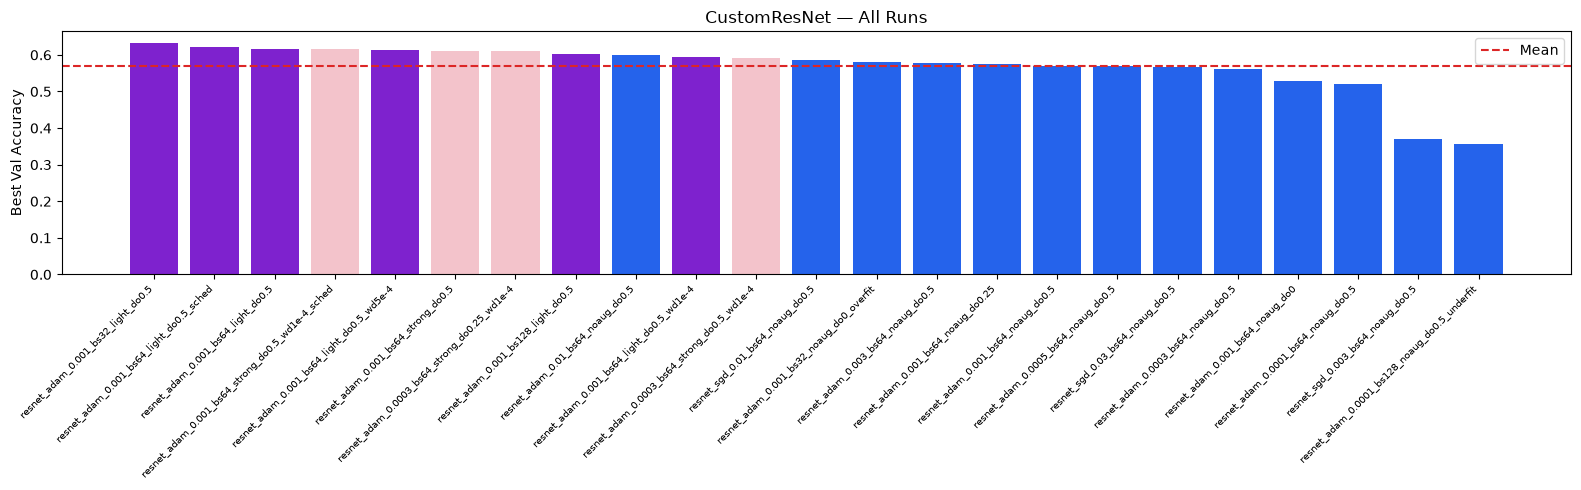

Generating charts:  12%|█▎        | 1/8 [00:00<00:06,  1.04it/s, current=LR Sweep]

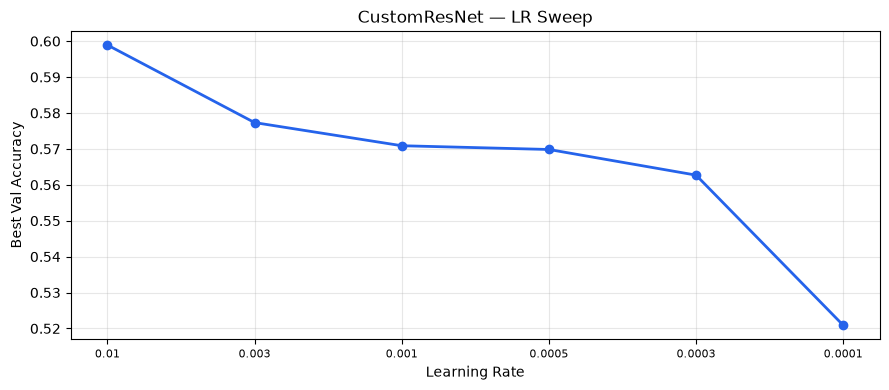

Generating charts:  25%|██▌       | 2/8 [00:01<00:03,  1.83it/s, current=Optimizer]

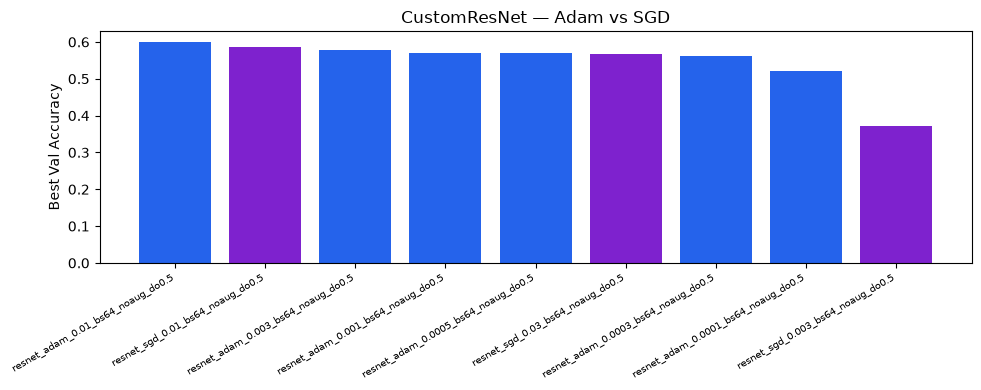

Generating charts:  38%|███▊      | 3/8 [00:01<00:02,  2.28it/s, current=Augmentation]

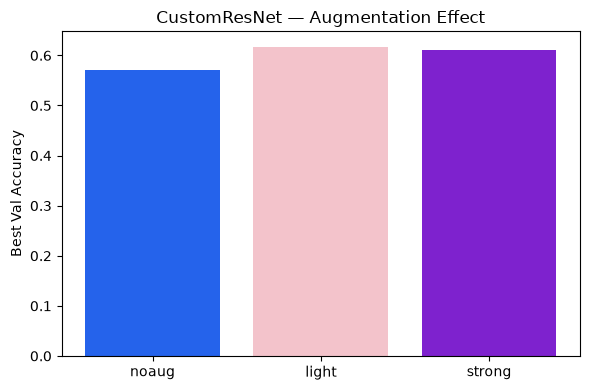

Generating charts:  50%|█████     | 4/8 [00:01<00:01,  3.09it/s, current=Dropout]     

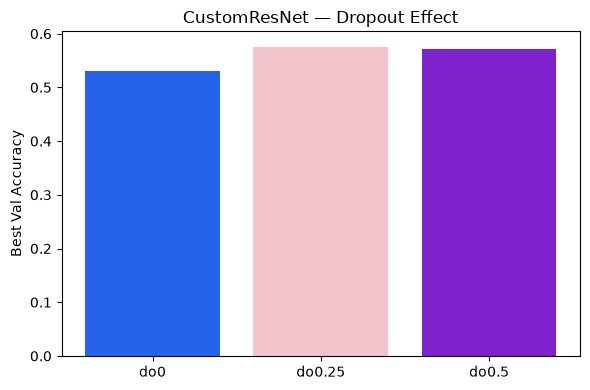

Generating charts:  62%|██████▎   | 5/8 [00:01<00:00,  3.84it/s, current=Weight Decay]

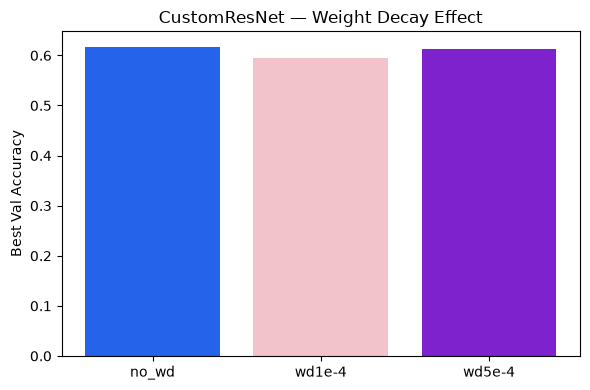

Generating charts:  75%|███████▌  | 6/8 [00:01<00:00,  4.47it/s, current=Best vs Overfit vs Underfit]

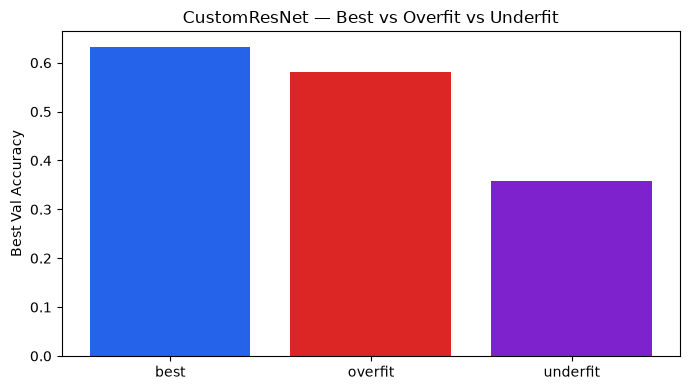

Generating charts:  88%|████████▊ | 7/8 [00:02<00:00,  4.85it/s, current=Confusion Matrix]           


Checkpoint: C:\Users\l.chitishvili\ml-assignment-Facial-Expression-Recognition\checkpoints\resnet_adam_0.001_bs32_light_do0.5_best.pt
Exists: True


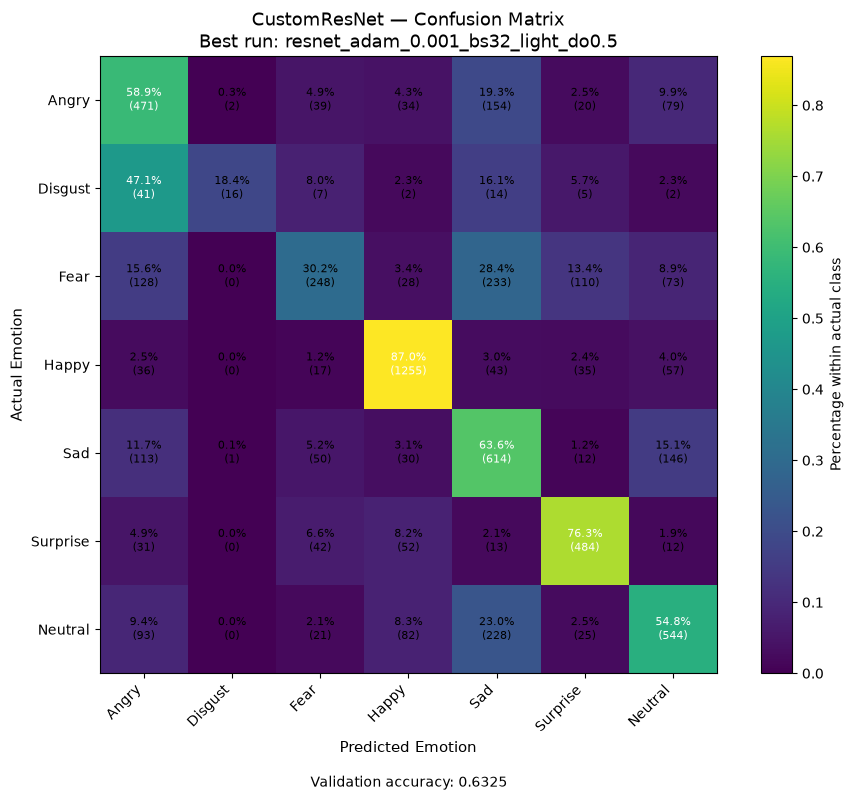

Generating charts: 100%|██████████| 8/8 [00:08<00:00,  1.07s/it, current=Confusion Matrix]



Best run: resnet_adam_0.001_bs32_light_do0.5
Best val_acc: 0.6327
All ResNet charts saved and logged to Wandb


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

BLUE   = '#2563EB'
PINK   = '#F3C3CB'
PURPLE = '#7E22CE'
RED    = '#DC2626'

results_df = pd.DataFrame(all_results).sort_values('best_val_acc', ascending=False)
print(results_df.to_string(index=False))

best_run_name = results_df.iloc[0]['run']
best_val_acc  = results_df.iloc[0]['best_val_acc']
print(f'\nBest run: {best_run_name} | val_acc: {best_val_acc:.4f}')

wandb.init(
    project='fer2013-expression-recognition',
    name='resnet_analysis',
    group='resnet',
    job_type='analysis'
)

charts = ['All Runs', 'LR Sweep', 'Optimizer', 'Augmentation',
          'Dropout', 'Weight Decay', 'Best vs Overfit vs Underfit', 'Confusion Matrix']
chart_bar = tqdm(charts, desc='Generating charts')

for chart_name in chart_bar:
    chart_bar.set_postfix(current=chart_name)

    if chart_name == 'All Runs':
        fig, ax = plt.subplots(figsize=(16, 5))
        colors = [BLUE if 'noaug' in r else PINK if 'strong' in r
                  else PURPLE for r in results_df['run']]
        ax.bar(results_df['run'], results_df['best_val_acc'], color=colors)
        ax.axhline(y=results_df['best_val_acc'].mean(), color=RED, linestyle='--', label='Mean')
        ax.set_xticks(range(len(results_df)))
        ax.set_xticklabels(results_df['run'], rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — All Runs')
        ax.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_bar.png'), dpi=200)
        wandb.log({'resnet_bar_chart': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'LR Sweep':
        lr_runs = [r for r in all_results if 'adam' in r['run']
                   and 'noaug' in r['run'] and 'do0.5' in r['run']
                   and 'wd' not in r['run'] and 'sched' not in r['run']
                   and 'bs64' in r['run'] and 'overfit' not in r['run']
                   and 'underfit' not in r['run']]
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(range(len(lr_runs)), [r['best_val_acc'] for r in lr_runs],
                'o-', color=BLUE, linewidth=2)
        ax.set_xticks(range(len(lr_runs)))
        ax.set_xticklabels([r['run'].split('_')[2] for r in lr_runs], fontsize=8)
        ax.set_xlabel('Learning Rate')
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — LR Sweep')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_lr.png'), dpi=200)
        wandb.log({'resnet_lr_effect': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Optimizer':
        opt_runs = [r for r in all_results if 'noaug' in r['run']
                    and 'do0.5' in r['run'] and 'wd' not in r['run']
                    and 'sched' not in r['run'] and 'overfit' not in r['run']
                    and 'underfit' not in r['run']]
        fig, ax = plt.subplots(figsize=(10, 4))
        colors = [BLUE if 'adam' in r['run'] else PURPLE for r in opt_runs]
        ax.bar([r['run'] for r in opt_runs],
               [r['best_val_acc'] for r in opt_runs], color=colors)
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — Adam vs SGD')
        plt.xticks(rotation=30, ha='right', fontsize=7)
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_optimizer.png'), dpi=200)
        wandb.log({'resnet_optimizer': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Augmentation':
        aug_data = [
            ('noaug',  next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_noaug_do0.5')),
            ('light',  next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_light_do0.5')),
            ('strong', next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_strong_do0.5')),
        ]
        aug_labels, aug_vals = zip(*aug_data)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(aug_labels, aug_vals, color=[BLUE, PINK, PURPLE])
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — Augmentation Effect')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_augmentation.png'), dpi=200)
        wandb.log({'resnet_augmentation': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Dropout':
        dropout_data = [
            ('do0',    next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_noaug_do0')),
            ('do0.25', next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_noaug_do0.25')),
            ('do0.5',  next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_noaug_do0.5')),
        ]
        do_labels, do_vals = zip(*dropout_data)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(do_labels, do_vals, color=[BLUE, PINK, PURPLE])
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — Dropout Effect')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_dropout.png'), dpi=200)
        wandb.log({'resnet_dropout': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Weight Decay':
        wd_data = [
            ('no_wd',  next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_light_do0.5')),
            ('wd1e-4', next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_light_do0.5_wd1e-4')),
            ('wd5e-4', next(r['best_val_acc'] for r in all_results if r['run'] == 'resnet_adam_0.001_bs64_light_do0.5_wd5e-4')),
        ]
        wd_labels, wd_vals = zip(*wd_data)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(wd_labels, wd_vals, color=[BLUE, PINK, PURPLE])
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — Weight Decay Effect')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_weightdecay.png'), dpi=200)
        wandb.log({'resnet_weightdecay': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Best vs Overfit vs Underfit':
        overfit_run  = next(r for r in all_results if 'overfit' in r['run'])
        underfit_run = next(r for r in all_results if 'underfit' in r['run'])
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(
            ['best', 'overfit', 'underfit'],
            [best_val_acc, overfit_run['best_val_acc'], underfit_run['best_val_acc']],
            color=[BLUE, RED, PURPLE]
        )
        ax.set_ylabel('Best Val Accuracy')
        ax.set_title('CustomResNet — Best vs Overfit vs Underfit')
        plt.tight_layout()
        plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_overfit_underfit.png'), dpi=200)
        wandb.log({'resnet_overfit_underfit': wandb.Image(fig)})
        plt.show()

    elif chart_name == 'Confusion Matrix':
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'{best_run_name}_best.pt')
        print(f'\nCheckpoint: {checkpoint_path}')
        print(f'Exists: {os.path.exists(checkpoint_path)}')

        if not os.path.exists(checkpoint_path):
            print('Checkpoint missing — skipping confusion matrix')
        else:
            dropout = 0.5 if 'do0.5' in best_run_name else 0.25 if 'do0.25' in best_run_name else 0.0
            _, val_loader, _ = get_dataloaders(data_dir=DATA_DIR, aug_mode='none', batch_size=128)
            model = CustomResNet(dropout=dropout).to(DEVICE)
            model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
            model.eval()

            all_preds, all_labels_list = [], []
            with torch.no_grad():
                for images, labels in val_loader:
                    outputs = model(images.to(DEVICE))
                    all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                    all_labels_list.extend(labels.numpy())

            all_preds = np.array(all_preds)
            all_labels_list = np.array(all_labels_list)
            val_accuracy = accuracy_score(all_labels_list, all_preds)

            wandb.log({
                'resnet_confusion_matrix_curve': wandb.plot.confusion_matrix(
                    y_true=all_labels_list,
                    preds=all_preds,
                    class_names=EMOTION_LABELS
                )
            })

            cm = confusion_matrix(all_labels_list, all_preds, labels=list(range(7)))
            cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True))

            fig, ax = plt.subplots(figsize=(10, 8))
            image = ax.imshow(cm_percent, interpolation='nearest')
            ax.set_title(f'CustomResNet — Confusion Matrix\nBest run: {best_run_name}', fontsize=13)
            ax.set_xlabel('Predicted Emotion', fontsize=11)
            ax.set_ylabel('Actual Emotion', fontsize=11)
            ax.set_xticks(np.arange(7))
            ax.set_yticks(np.arange(7))
            ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha='right')
            ax.set_yticklabels(EMOTION_LABELS)

            for i in range(7):
                for j in range(7):
                    ax.text(j, i,
                            f'{cm_percent[i,j]*100:.1f}%\n({cm[i,j]})',
                            ha='center', va='center', fontsize=8,
                            color='white' if cm_percent[i,j] > 0.45 else 'black')

            fig.colorbar(image, ax=ax).set_label('Percentage within actual class')
            fig.text(0.5, 0.01, f'Validation accuracy: {val_accuracy:.4f}', ha='center', fontsize=10)
            plt.tight_layout(rect=[0, 0.03, 1, 1])
            plt.savefig(os.path.join(CHECKPOINT_DIR, 'resnet_confusion_matrix.png'), dpi=200)
            wandb.log({'resnet_confusion_matrix_chart': wandb.Image(fig)})
            plt.show()

wandb.finish()
print(f'\nBest run: {best_run_name}')
print(f'Best val_acc: {best_val_acc:.4f}')
print('All ResNet charts saved and logged to Wandb')
